# CBA Ensemble -- Sandbox

Interactive sandbox for the CBA Ensemble strategy (short TSLL + delta-neutral long call, cheapest of TSLA vs TSLL each roll). Reuses the production logic in `scripts/backtest/cba_backtest.py`, `options_selection.py`, and `borrow_rates.py` -- nothing here re-derives the simulation, it just exposes the parameters for quick interactive tweaking and plotting.

For the full parameter grid (all DTE x roll x bucket combinations, all 4 cost scenarios), see `scripts/backtest/grid_search.py` instead -- this notebook is for poking at *one* configuration at a time.

**Note:** this notebook has not been executed. `jupyter`/`ipykernel` aren't in `requirements.txt` yet -- install them in the venv before running (`pip install jupyter ipykernel`).

In [21]:
%load_ext autoreload
%autoreload 2
# autoreload re-imports cba_backtest.py/grid_search.py automatically whenever they change on
# disk, so editing the production scripts doesn't require restarting this kernel each time.

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from metrics import summarize
from cba_backtest import simulate_ensemble, BUCKETS
from grid_search import load_data  # builds spot/options/sigma/borrow series once

# cba_backtest.py / grid_search.py both call matplotlib.use("Agg") at import time
# (so the standalone scripts can save PNGs headless) -- that silently overrides any
# inline backend set before this point, which is why plots weren't rendering. Re-assert
# inline mode *after* importing them, not before.
%matplotlib inline

print("Buckets available:", BUCKETS)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Buckets available: ['ATM', '10% OTM', '20% OTM']


## Parameters -- edit these and re-run

| Param | Meaning |
|---|---|
| `BUCKET` | Moneyness bucket: `"ATM"`, `"10% OTM"`, or `"20% OTM"` |
| `TARGET_DTE` | Days-to-expiry targeted at entry (project cap: 180) |
| `ROLL_DTE` | Roll once held DTE drops below this |
| `MAX_DTE` | Upper bound when searching for a contract (small buffer over `TARGET_DTE`, not a wide search) |
| `STOP_LOSS_PCT` | Switch early if unrealized loss vs. entry premium breaches this (`None` to disable) |
| `TSLA_COST_PCT` / `TSLL_COST_PCT` | Baseline per-leg transaction cost (fraction of premium), scaled internally by realized vol + that contract's own volume |
| `INCLUDE_BORROW` | Whether to charge the real TSLL borrow-fee series (see `borrow_rates.py`) on the short notional |

In [22]:
BUCKET = "10% OTM"
TARGET_DTE = 90
ROLL_DTE = 14
MAX_DTE = 200
STOP_LOSS_PCT = 0.5

# Cost scenario -- pick one of grid_search.py's COST_SCENARIOS, or set your own.
TSLA_COST_PCT = 0.010   # 1%/leg baseline (2% round-trip)
TSLL_COST_PCT = 0.030   # 3%/leg baseline (6% round-trip)
INCLUDE_BORROW = True

## Load data (once)

Reuses `grid_search.load_data()` -- spot series, option chains, price/volume lookups, realized-vol series, and the real TSLL borrow-rate series, all built exactly the way the production grid does it.

In [23]:
data = load_data()
(returns, tsla_calls, tsla_spot, tsla_lookup, tsla_vol_lookup, tsla_sigma,
 tsll_calls, tsll_spot, tsll_lookup, tsll_vol_lookup, tsll_sigma, borrow_df) = data

print(f"Window: {returns.index.min().date()} -> {returns.index.max().date()}  ({len(returns)} trading days)")
print(f"TSLL borrow rate: mean={borrow_df['TSLL'].mean():.1%}  min={borrow_df['TSLL'].min():.1%}  max={borrow_df['TSLL'].max():.1%}")

Window: 2022-08-12 -> 2026-06-10  (960 trading days)
TSLL borrow rate: mean=3.9%  min=0.7%  max=7.0%


## Run one simulation with the parameters above

In [24]:
tsll_borrow_rate = borrow_df["TSLL"] if INCLUDE_BORROW else None

equity, stats = simulate_ensemble(
    returns,
    tsla_calls, tsla_spot, tsla_lookup, tsla_vol_lookup, tsla_sigma,
    tsll_calls, tsll_spot, tsll_lookup, tsll_vol_lookup, tsll_sigma,
    BUCKET, TARGET_DTE, ROLL_DTE, MAX_DTE,
    stop_loss_pct=STOP_LOSS_PCT,
    tsla_cost_pct=TSLA_COST_PCT, tsll_cost_pct=TSLL_COST_PCT,
    tsll_borrow_rate=tsll_borrow_rate,
)
equity = equity / equity.iloc[0]

row = summarize(equity, equity.pct_change().dropna(), f"{BUCKET} / {TARGET_DTE}d / roll@{ROLL_DTE}d")
row.update(stats)
pd.Series(row)

Strategy                                           10% OTM / 90d / roll@14d
CAGR                                                               0.180451
Ann. Vol                                                           0.333794
Sharpe                                                             0.664186
Max DD                                                            -0.268062
Calmar                                                             0.673168
roll_attempts                                                            14
fills                                                                    14
fills_tsla                                                                6
fills_tsll                                                                8
misses                                                                    0
miss_dates                                                               []
hedge_cost                                                         5.175333
stop_loss_ro

Key `stats` fields to sanity-check, not just the headline metrics:
- `fills` / `misses` -- entry fill rate (a `select_contract()` miss when no contract had real volume in the bucket that day)
- `exit_misses` -- times a roll/switch was *wanted* but the held contract had no fill that day, so the position was held instead
- `stop_loss_rolls` -- times the stop-loss override actually executed a switch (only when the savings cleared the switching cost)
- `transaction_costs_paid` / `borrow_paid` -- cumulative dollar drag from each cost source

## Plot equity curve + drawdown

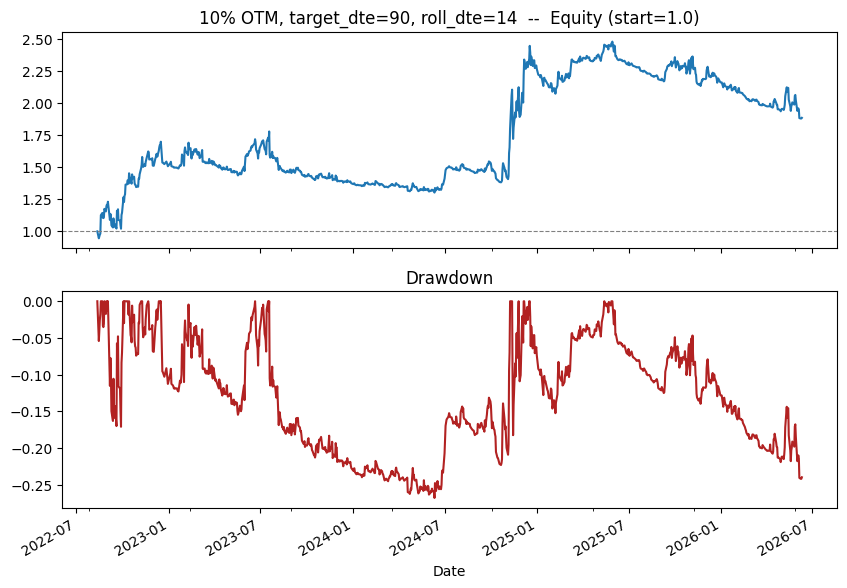

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

equity.plot(ax=axes[0])
axes[0].set_title(f"{BUCKET}, target_dte={TARGET_DTE}, roll_dte={ROLL_DTE}  --  Equity (start=1.0)")
axes[0].axhline(1.0, color="grey", linestyle="--", linewidth=0.8)

dd = equity / equity.cummax() - 1
dd.plot(ax=axes[1], color="firebrick")
axes[1].set_title("Drawdown")

plt.show()

## Hedge ratio (n) over time

`n` is the number of contracts held, recomputed at every roll/stop-loss switch (see `stats["n_series"]`). It is **not** constant -- it grows as `cum_TSLL` grows (TSLL appreciating means a bigger short to cover) and resets at every roll based on whichever underlying/bucket was cheapest that day. Gaps in the line are unhedged days (a miss).

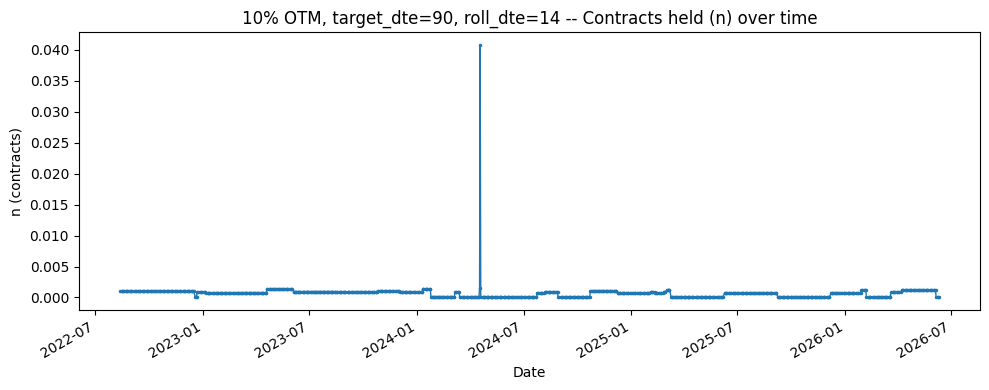

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))
stats["n_series"].plot(ax=ax, marker=".", markersize=3, linewidth=1)
ax.set_title(f"{BUCKET}, target_dte={TARGET_DTE}, roll_dte={ROLL_DTE} -- Contracts held (n) over time")
ax.set_ylabel("n (contracts)")
fig.tight_layout()

## Delta-neutrality drift over time

Coverage ratio = (hedge's dollar delta) / (target dollar delta being hedged). It is solved to exactly 1.0 at the instant a position is sized (see `stats["coverage_series"]`), but `n` then stays fixed until the next roll or stop-loss switch while spot, time-to-expiry, and volatility keep moving the option's actual delta -- so the position drifts away from delta-neutral and only gets corrected at the next rebalancing date. Dashed vertical lines below mark every rebalancing date (scheduled roll or stop-loss switch), detected from `n_series` changing value.

Rebalancing dates: 39
count    960.000000
mean       1.215698
std        0.507924
min        0.024637
25%        0.971627
50%        1.161996
75%        1.518225
max        3.187150
dtype: float64


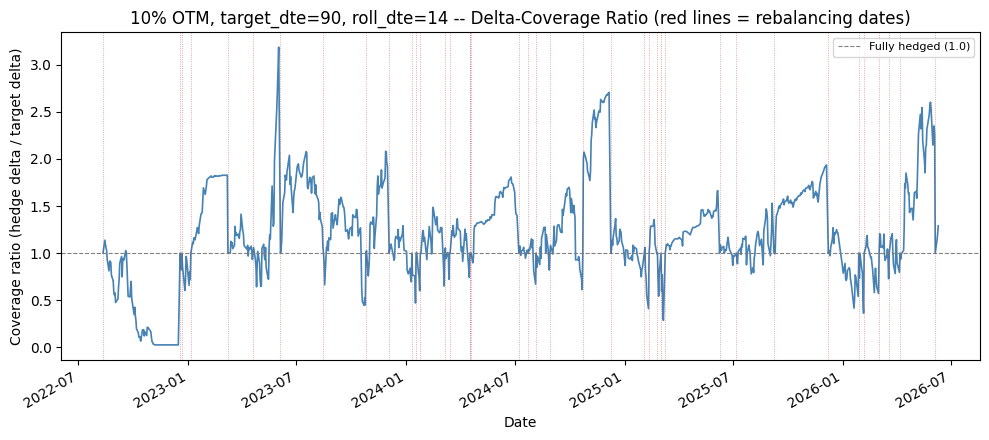

In [27]:
coverage = stats["coverage_series"]
n = stats["n_series"]
rebalance_dates = n.index[(n.fillna(-1).diff().fillna(1) != 0) & n.notna()]

fig, ax = plt.subplots(figsize=(10, 4.5))
coverage.plot(ax=ax, linewidth=1.2, color="steelblue")
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, label="Fully hedged (1.0)")
for rd in rebalance_dates:
    ax.axvline(rd, color="firebrick", linestyle=":", linewidth=0.6, alpha=0.5)
ax.set_title(f"{BUCKET}, target_dte={TARGET_DTE}, roll_dte={ROLL_DTE} -- "
             "Delta-Coverage Ratio (red lines = rebalancing dates)")
ax.set_ylabel("Coverage ratio (hedge delta / target delta)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()

print(f"Rebalancing dates: {len(rebalance_dates)}")
print(coverage.describe())

## Coverage-band trigger -- sandbox-only experiment

`simulate_ensemble()` now accepts an optional `coverage_band=(low, high)` parameter: if the delta-coverage ratio drifts outside this band, the position is resized in place (same bucket/underlying, re-priced fresh at today's spot/vol/T) unconditionally -- no cost-benefit gate. This is deliberately a *separate* mechanism from the stop-loss override, not a shared one: a systemic move (e.g. a crash) decays every bucket/underlying's premium together, so "is there a cheaper alternative" rarely clears during exactly the move this is meant to catch. An earlier version reused the stop-loss's cost-gated switch logic for this trigger too, and it made results *worse* across the board -- it never fired during the actual crash (no alternative cleared its cost hurdle) but did fire opportunistically elsewhere, just paying extra transaction costs for no protection. Separating the two -- cost-driven switch for stop-loss, unconditional risk-driven resize for coverage-band -- is the corrected design below.

This parameter defaults to `None` everywhere else (`cba_backtest.py main()`, `grid_search.py`) -- it does not change the published CBA table or the grid results. It only ever gets exercised here, by explicitly passing it below, so we can compare with/without before deciding whether it's worth promoting into the production grid.

In [28]:
COVERAGE_BAND = (0.5, 2.0)  # tune and re-run -- tighter band = more frequent corrective switches

equity_baseline, stats_baseline = simulate_ensemble(
    returns,
    tsla_calls, tsla_spot, tsla_lookup, tsla_vol_lookup, tsla_sigma,
    tsll_calls, tsll_spot, tsll_lookup, tsll_vol_lookup, tsll_sigma,
    BUCKET, TARGET_DTE, ROLL_DTE, MAX_DTE,
    stop_loss_pct=STOP_LOSS_PCT,
    tsla_cost_pct=TSLA_COST_PCT, tsll_cost_pct=TSLL_COST_PCT,
    tsll_borrow_rate=tsll_borrow_rate,
    coverage_band=None,  # baseline -- identical to the production default
)
equity_baseline = equity_baseline / equity_baseline.iloc[0]

equity_banded, stats_banded = simulate_ensemble(
    returns,
    tsla_calls, tsla_spot, tsla_lookup, tsla_vol_lookup, tsla_sigma,
    tsll_calls, tsll_spot, tsll_lookup, tsll_vol_lookup, tsll_sigma,
    BUCKET, TARGET_DTE, ROLL_DTE, MAX_DTE,
    stop_loss_pct=STOP_LOSS_PCT,
    tsla_cost_pct=TSLA_COST_PCT, tsll_cost_pct=TSLL_COST_PCT,
    tsll_borrow_rate=tsll_borrow_rate,
    coverage_band=COVERAGE_BAND,  # sandbox-only feature, switched on here
)
equity_banded = equity_banded / equity_banded.iloc[0]

compare_rows = [
    summarize(equity_baseline, equity_baseline.pct_change().dropna(), "Baseline (no coverage band)"),
    summarize(equity_banded, equity_banded.pct_change().dropna(), f"Coverage band {COVERAGE_BAND}"),
]
for row, stats_i in zip(compare_rows, [stats_baseline, stats_banded]):
    row["stop_loss_rolls"] = stats_i["stop_loss_rolls"]
    row["coverage_band_rolls"] = stats_i["coverage_band_rolls"]
    row["transaction_costs_paid"] = stats_i["transaction_costs_paid"]
    row["exit_misses"] = stats_i["exit_misses"]
pd.DataFrame(compare_rows)

,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar,stop_loss_rolls,coverage_band_rolls,transaction_costs_paid,exit_misses
0,Baseline (no coverage band),0.180451,0.333794,0.664186,-0.268062,0.673168,25,0,0.202556,13
1,"Coverage band (0.5, 2.0)",0.081699,0.332131,0.401100,-0.365927,0.223265,26,5,0.262106,13


## Compare: equity curves and coverage ratio, with vs. without the band trigger

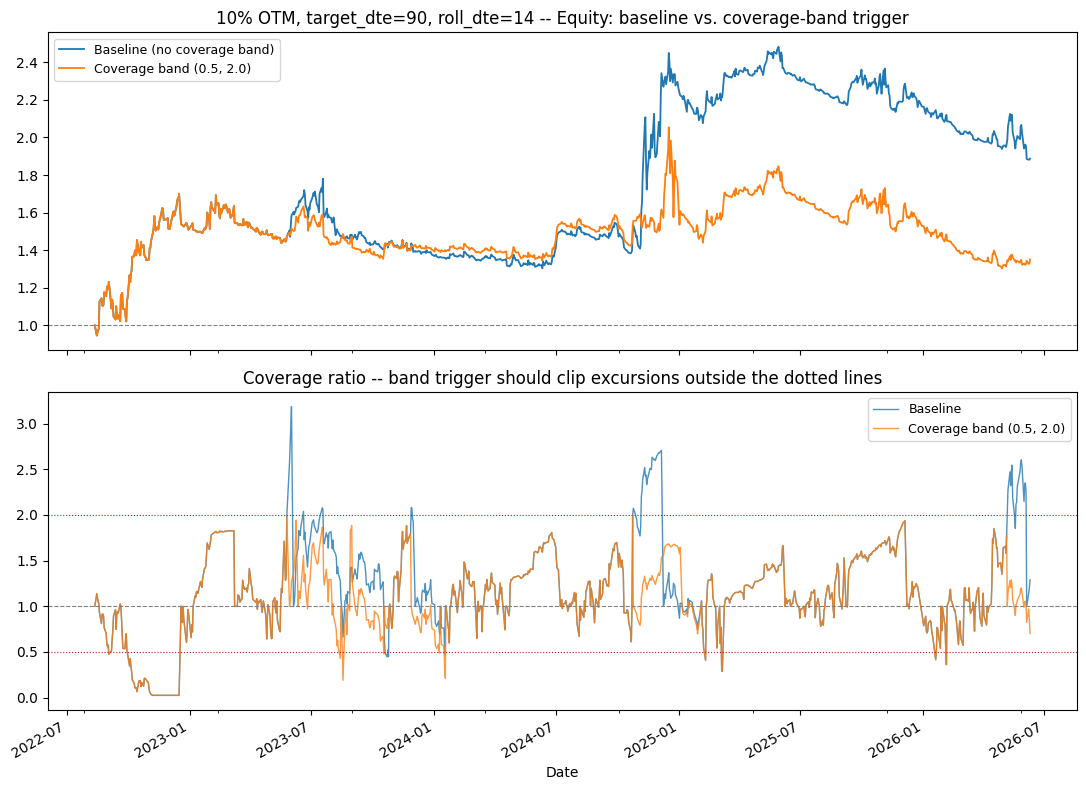

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

equity_baseline.plot(ax=axes[0], label="Baseline (no coverage band)", linewidth=1.3)
equity_banded.plot(ax=axes[0], label=f"Coverage band {COVERAGE_BAND}", linewidth=1.3)
axes[0].axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
axes[0].set_title(f"{BUCKET}, target_dte={TARGET_DTE}, roll_dte={ROLL_DTE} -- Equity: baseline vs. coverage-band trigger")
axes[0].legend(fontsize=9)

stats_baseline["coverage_series"].plot(ax=axes[1], label="Baseline", linewidth=1.0, alpha=0.8)
stats_banded["coverage_series"].plot(ax=axes[1], label=f"Coverage band {COVERAGE_BAND}", linewidth=1.0, alpha=0.8)
axes[1].axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
axes[1].axhline(COVERAGE_BAND[0], color="firebrick", linestyle=":", linewidth=0.8)
axes[1].axhline(COVERAGE_BAND[1], color="firebrick", linestyle=":", linewidth=0.8)
axes[1].set_title("Coverage ratio -- band trigger should clip excursions outside the dotted lines")
axes[1].legend(fontsize=9)

fig.tight_layout()

## Quick sweep (optional)

Not the full grid -- just a handful of `TARGET_DTE` values at the fixed `ROLL_DTE`/bucket/costs above, for a fast visual sense of the trade-off before going to `grid_search.py` for the exhaustive version.

,Strategy,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
0,target_dte=30,0.084563,0.285064,0.427001,-0.458228,0.184543
1,target_dte=60,0.171847,0.302397,0.676249,-0.327748,0.524326
2,target_dte=90,0.180451,0.333794,0.664186,-0.268062,0.673168
3,target_dte=120,0.080313,0.326766,0.399376,-0.268862,0.298714
4,target_dte=180,0.204971,0.376071,0.684318,-0.258015,0.794414


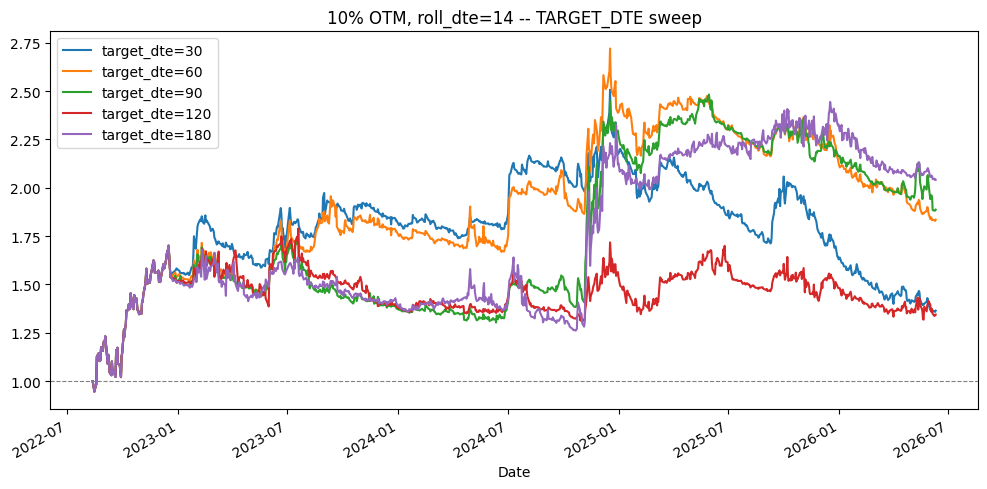

In [30]:
SWEEP_TARGET_DTES = [30, 60, 90, 120, 180]

fig, ax = plt.subplots(figsize=(10, 5))
sweep_rows = []
for dte in SWEEP_TARGET_DTES:
    eq_i, stats_i = simulate_ensemble(
        returns,
        tsla_calls, tsla_spot, tsla_lookup, tsla_vol_lookup, tsla_sigma,
        tsll_calls, tsll_spot, tsll_lookup, tsll_vol_lookup, tsll_sigma,
        BUCKET, dte, ROLL_DTE, MAX_DTE,
        stop_loss_pct=STOP_LOSS_PCT,
        tsla_cost_pct=TSLA_COST_PCT, tsll_cost_pct=TSLL_COST_PCT,
        tsll_borrow_rate=tsll_borrow_rate,
    )
    eq_i = eq_i / eq_i.iloc[0]
    eq_i.plot(ax=ax, label=f"target_dte={dte}")
    sweep_rows.append(summarize(eq_i, eq_i.pct_change().dropna(), f"target_dte={dte}"))

ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title(f"{BUCKET}, roll_dte={ROLL_DTE} -- TARGET_DTE sweep")
ax.legend()
fig.tight_layout()

pd.DataFrame(sweep_rows)